# 🏦 Credit Risk Analyzer — Teaching Notebook

## ML + LLM in a Real-World Finance Use Case

**What you will learn:**
1. How to generate synthetic tabular data for a finance problem
2. How to train a `RandomForestClassifier` for binary credit scoring
3. How to interpret model outputs (probability, feature importance)
4. How to call the OpenAI API to turn model scores into a human-readable letter
5. How all of this fits together in a deployable Streamlit app

---
> **Audience:** Python learners comfortable with Pandas and basic ML concepts  
> **Repo structure:** Everything lives in one flat directory for simplicity


---
## Part 1 — The Problem & Dataset

### 1.1  The Business Problem

A bank needs to decide: *should we approve this loan application?*

Traditionally a human loan officer reviewed each file.  
Today banks use **credit scoring models** — statistical models that output a probability of default.

We will build a simplified version of that pipeline.

### 1.2  What features matter in credit scoring?

| Feature | Why it matters |
|---------|---------------|
| Annual Income | Higher income → more capacity to repay |
| Loan Amount | Larger loan → higher risk |
| Debt-to-Income (DTI) | How much existing debt relative to income |
| Credit History (years) | Longer history → more track record |
| Late Payments | Direct signal of repayment behaviour |
| Employment Duration | Job stability |
| Open Accounts | Too few or too many can be risky |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')


In [16]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# ── Reproducibility
SEED = 42
np.random.seed(SEED)

# ── 1. Synthetic Dataset
N = 2000

annual_income       = np.random.normal(60_000, 25_000, N).clip(15_000, 250_000)
loan_amount         = np.random.normal(15_000, 8_000,  N).clip(1_000,  80_000)
credit_history_yrs  = np.random.randint(0, 25, N).astype(float)
num_late_payments   = np.random.poisson(1.5, N).clip(0, 15)
debt_to_income      = (loan_amount / annual_income).clip(0.01, 0.95)
employment_yrs      = np.random.randint(0, 30, N).astype(float)
num_open_accounts   = np.random.randint(1, 12, N).astype(float)

# Deterministic approval rule (ground truth)
score = (
     0.35 * (annual_income / 250_000)
   + 0.25 * (credit_history_yrs / 25)
   - 0.20 * debt_to_income
   - 0.15 * (num_late_payments / 15)
   + 0.05 * (employment_yrs / 30)
)
noise    = np.random.normal(0, 0.08, N)
approved = ((score + noise) > 0.35).astype(int)

df = pd.DataFrame({
    "annual_income":      annual_income.round(2),
    "loan_amount":        loan_amount.round(2),
    "credit_history_yrs": credit_history_yrs,
    "num_late_payments":  num_late_payments,
    "debt_to_income":     debt_to_income.round(4),
    "employment_yrs":     employment_yrs,
    "num_open_accounts":  num_open_accounts,
    "approved":           approved,
})

df.to_csv("sample_data.csv", index=False)
print(f"✅  sample_data.csv saved  ({len(df)} rows, "
      f"approval rate: {df.approved.mean():.1%})")


✅  sample_data.csv saved  (2000 rows, approval rate: 6.6%)


In [1]:

# Load the pre-generated data (created by train_model.py)
df = pd.read_csv("sample_data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (2000, 8)


,annual_income,loan_amount,credit_history_yrs,num_late_payments,debt_to_income,employment_yrs,num_open_accounts,approved
0,72417.85,9598.57,23.0,3,0.1325,25.0,5.0,0
1,56543.39,13843.85,18.0,2,0.2448,15.0,7.0,0
2,76192.21,8660.64,9.0,1,0.1137,11.0,3.0,0
3,98075.75,12536.31,23.0,1,0.1278,6.0,1.0,0
4,54146.17,1000.00,7.0,4,0.0185,15.0,1.0,0


In [2]:
# Basic statistics
df.describe().round(2)

,annual_income,loan_amount,credit_history_yrs,num_late_payments,debt_to_income,employment_yrs,num_open_accounts,approved
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,61421.52,15078.05,11.97,1.46,0.30,14.51,5.91,0.07
std,24043.17,7771.87,7.24,1.16,0.22,8.71,3.18,0.25
min,15000.00,1000.00,0.00,0.00,0.01,0.00,1.00,0.00
25%,44433.46,9326.99,6.00,1.00,0.15,7.00,3.00,0.00
50%,61117.30,14999.58,12.00,1.00,0.25,15.00,6.00,0.00
75%,77074.44,20324.34,18.00,2.00,0.38,22.00,9.00,0.00
max,156318.29,46409.90,24.00,7.00,0.95,29.00,11.00,1.00


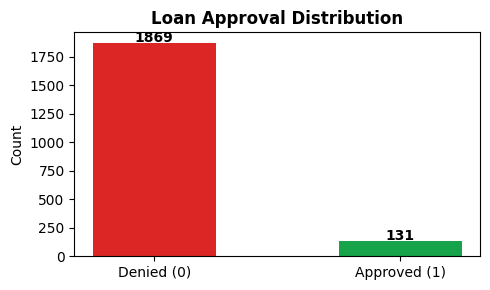

Approval rate: 6.6%


In [3]:
# Class balance — how many loans were approved vs denied?
counts = df['approved'].value_counts()
labels = ['Denied (0)', 'Approved (1)']

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, counts.values, color=['#dc2626', '#16a34a'], width=0.5)
ax.set_title('Loan Approval Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

approval_rate = df['approved'].mean()
print(f"Approval rate: {approval_rate:.1%}")


---
## Part 2 — Exploratory Data Analysis (EDA)

Before training, always look at how features relate to the target.


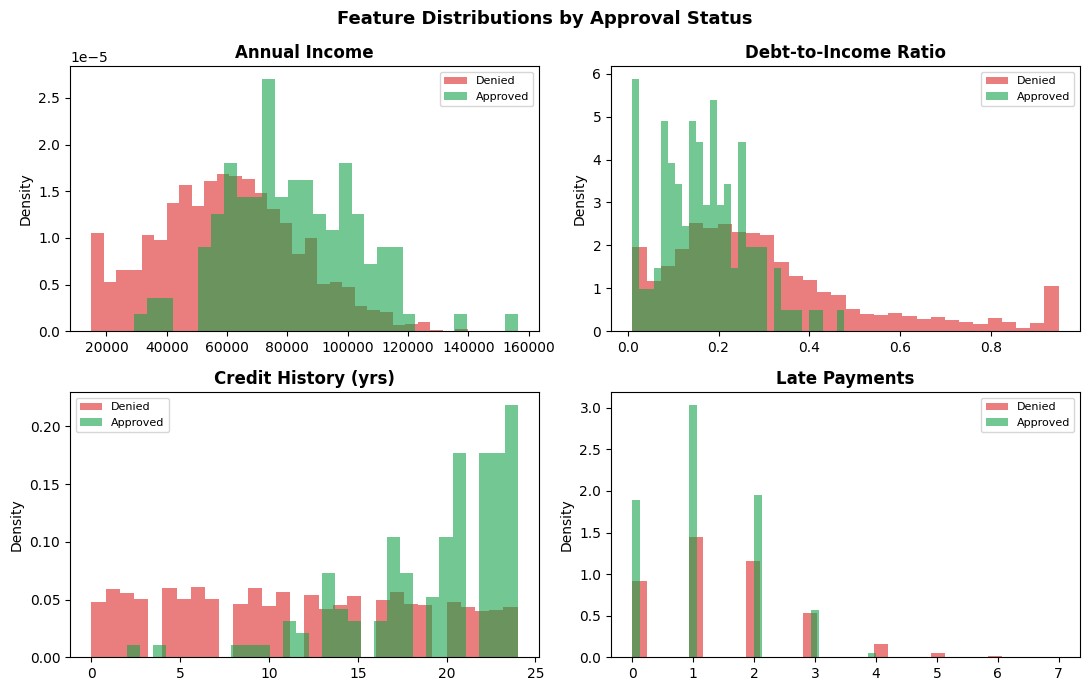

In [4]:
# Distribution of key features by approval status
features_to_plot = [
    'annual_income', 'debt_to_income', 'credit_history_yrs', 'num_late_payments'
]
titles = [
    'Annual Income', 'Debt-to-Income Ratio', 'Credit History (yrs)', 'Late Payments'
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(features_to_plot, titles)):
    denied   = df.loc[df.approved == 0, feat]
    approved = df.loc[df.approved == 1, feat]
    axes[i].hist(denied,   bins=30, alpha=0.6, color='#dc2626', label='Denied',   density=True)
    axes[i].hist(approved, bins=30, alpha=0.6, color='#16a34a', label='Approved', density=True)
    axes[i].set_title(title, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions by Approval Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


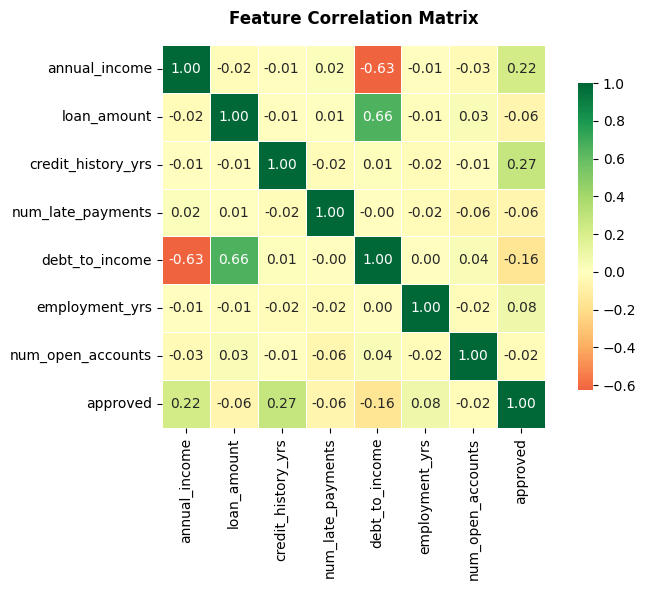

Correlations with 'approved':
approved              1.000000
credit_history_yrs    0.273035
annual_income         0.220056
employment_yrs        0.082833
num_open_accounts    -0.022929
num_late_payments    -0.064006
loan_amount          -0.064173
debt_to_income       -0.155503


In [5]:
# Correlation heatmap
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Teaching note: what correlates most strongly with 'approved'?
print("Correlations with 'approved':")
print(corr['approved'].sort_values(ascending=False).to_string())


---
## Part 3 — Training the ML Model

We use a **Random Forest Classifier** — an ensemble of decision trees.

### Why Random Forest?
- Works well out-of-the-box on tabular data
- Handles non-linear relationships
- Provides **feature importances** — great for explainability
- Robust to outliers

### The ML Pipeline

```
Raw Features → Train/Test Split → RandomForestClassifier → Probability Score
```


In [6]:
FEATURES = [
    'annual_income', 'loan_amount', 'credit_history_yrs',
    'num_late_payments', 'debt_to_income', 'employment_yrs', 'num_open_accounts',
]

X = df[FEATURES]
y = df['approved']


In [7]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test — stratified so class balance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"\nClass balance in test set:")
print(y_test.value_counts())


Train size : 1600
Test size  : 400

Class balance in test set:
approved
0    374
1     26
Name: count, dtype: int64


In [8]:
# Train the model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,   # number of trees
    max_depth=8,        # max tree depth (prevents overfitting)
    min_samples_leaf=10,
    class_weight='balanced',  # handles class imbalance automatically
    random_state=42,
)

model.fit(X_train, y_train)
print("✅ Model trained!")


✅ Model trained!


In [9]:
from sklearn.metrics import (classification_report, 
                             roc_auc_score,
                              RocCurveDisplay, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay)

# Evaluate on test set
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of approval

print("── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

      Denied       0.98      0.89      0.93       374
    Approved       0.31      0.69      0.42        26

    accuracy                           0.88       400
   macro avg       0.64      0.79      0.68       400
weighted avg       0.93      0.88      0.90       400

ROC-AUC: 0.8614


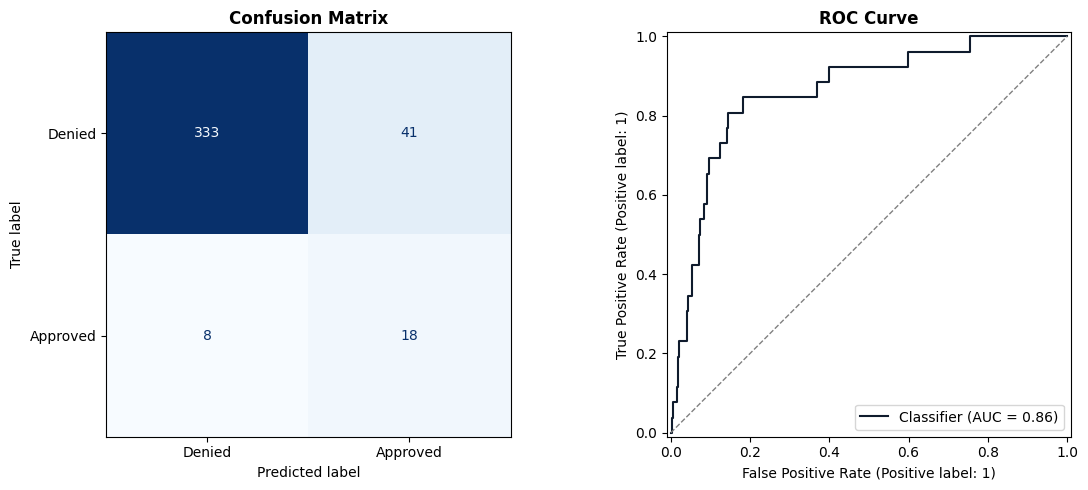

In [10]:
# Visualise: Confusion Matrix + ROC Curve side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied', 'Approved'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color='#0f1b2d')
ax2.plot([0,1],[0,1],'--', color='grey', linewidth=1)
ax2.set_title('ROC Curve', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Part 4 — Interpreting the Model

### Feature Importances

Random Forest tells us *which features mattered most* for the predictions.  
This is essential in finance for **model explainability** and regulatory compliance.


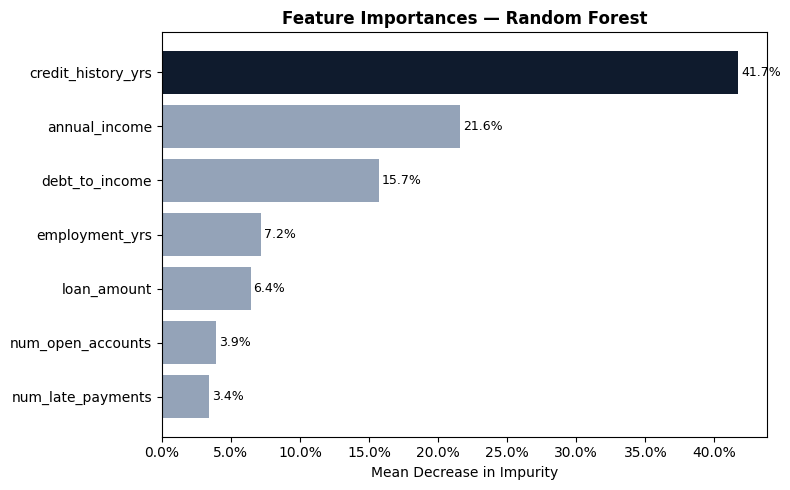

In [11]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#0f1b2d' if v == importances.max() else '#94a3b8' for v in importances.values]
ax.barh(importances.index, importances.values, color=colors)
ax.set_title('Feature Importances — Random Forest', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
# Teaching exercise: predict for a single applicant
sample_applicant = {
    'annual_income':      75_000,
    'loan_amount':        18_000,
    'credit_history_yrs': 7,
    'num_late_payments':  1,
    'debt_to_income':     18_000 / 75_000,
    'employment_yrs':     5,
    'num_open_accounts':  4,
}

X_sample = pd.DataFrame([sample_applicant])[FEATURES]
prob = model.predict_proba(X_sample)[0][1]
decision = 'APPROVED ✅' if prob >= 0.5 else 'DENIED ❌'

print(f"Approval Probability : {prob:.1%}")
print(f"Decision             : {decision}")


Approval Probability : 5.4%
Decision             : DENIED ❌


# Save the model

In [14]:
import joblib

# 1. Create the bundle dictionary expected by your loading script
model_bundle = {
    "model": model,  # Replace with your actual model variable (e.g., model, lr, clf)
    "features": list(X_train.columns)  # Replace with your actual training features DataFrame
}

# 2. Save the bundle to a file
joblib.dump(model_bundle, "credit_model.pkl")

print("Model bundle successfully saved to credit_model.pkl")


Model bundle successfully saved to credit_model.pkl


In [15]:
# Quick sanity check — load the saved model and score the same applicant
import joblib

bundle  = joblib.load("credit_model.pkl")
model2  = bundle["model"]
feats   = bundle["features"]

X2 = pd.DataFrame([sample_applicant])[feats]
prob2 = model2.predict_proba(X2)[0][1]

print(f"Probability from loaded model : {prob2:.1%}")
print("(Should match the value computed earlier)")


Probability from loaded model : 5.4%
(Should match the value computed earlier)


---
## Part 5 — OpenAI: From Score to Human-Readable Letter

The ML model outputs a *number*.  
A customer needs to receive a *letter*.

This is where **Large Language Models** shine:  
they take structured data and produce fluent, context-aware prose.

### Regulatory context
In the US, if a bank denies a loan it must send an **Adverse Action Notice** under:
- **ECOA** (Equal Credit Opportunity Act)
- **FCRA** (Fair Credit Reporting Act)

These laws require the bank to list **specific reasons** for denial.  
Our prompt instructs GPT-4o-mini to follow these rules.

---
> ⚠️ **Set your API key before running the next cell.**


In [ ]:
# ── Install openai if running this notebook standalone ──
# !pip install openai -q

from openai import OpenAI

# Replace with your key, or load from an environment variable
# import os; openai_key = os.environ["OPENAI_API_KEY"]
openai_key = "sk-..."   # ← paste your key here for the notebook demo

client = OpenAI(api_key=openai_key)


In [ ]:
def generate_credit_letter(applicant: dict, approval_prob: float, decision: str) -> str:
    """
    Call GPT-4o-mini to write a formal bank letter based on the ML model output.
    
    Parameters
    ----------
    applicant      : dict of feature values
    approval_prob  : float, probability from model.predict_proba
    decision       : 'APPROVED' or 'DENIED'
    
    Returns
    -------
    letter : str
    """
    dti = applicant['debt_to_income']

    prompt = f"""You are a senior loan officer at a U.S. regulated bank.
Based on the automated credit scoring result below, write a formal bank letter to the applicant.

─── Credit Score Summary ───
Decision       : {decision}
Approval Prob. : {approval_prob:.1%}
Annual Income  : ${applicant['annual_income']:,.0f}
Loan Requested : ${applicant['loan_amount']:,.0f}
Debt-to-Income : {dti:.1%}
Credit History : {applicant['credit_history_yrs']} years
Late Payments  : {applicant['num_late_payments']}
Employment     : {applicant['employment_yrs']} years
Open Accounts  : {applicant['num_open_accounts']}
────────────────────────────

Instructions:
- If APPROVED  : write a warm, professional approval letter with the loan amount and next steps.
- If DENIED    : write an adverse-action notice complying with ECOA and FCRA.
                 List the specific reasons for denial based on the data above.
- Use formal letter format: date, salutation, body paragraphs, closing, signature block.
- Do NOT invent figures not listed above.
- Keep the letter under 350 words.
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.4,
        max_tokens=600,
    )
    return response.choices[0].message.content


# ── Run for our sample applicant ─────────────────────────────────────────────
letter = generate_credit_letter(
    applicant=sample_applicant,
    approval_prob=prob,
    decision=decision.replace(' ✅','').replace(' ❌',''),
)
print(letter)


---
## Part 6 — Putting It Together: The Streamlit App

The file `app.py` wires everything from this notebook into a web UI:

```
User (Streamlit sliders)
        │
        ▼
   Derived Features
   (debt_to_income = loan / income)
        │
        ▼
 RandomForestClassifier ──► approval_prob  ──► Decision Banner
        │
        ▼
  OpenAI GPT-4o-mini ──────────────────────► Formal Letter
```

### Running locally
```bash
pip install -r requirements.txt
streamlit run app.py
```

### Deploying to Streamlit Cloud
1. Push all files to a **public GitHub repo**
2. Go to [share.streamlit.io](https://share.streamlit.io)
3. Connect your repo → select `app.py` as the entry point
4. Click **Deploy** — done!

> The `credit_model.pkl` file must be committed to the repo so Streamlit Cloud can load it.


# OPTIONAL

---
## Part 7 — Exercises for Students

Try these modifications to deepen your understanding:

### 🟢 Beginner
1. Change a slider value in `app.py` and observe how the probability changes.
2. In this notebook, create a **denied** applicant profile and generate their adverse-action letter.

### 🟡 Intermediate
3. Replace `RandomForestClassifier` with `LogisticRegression`. Compare ROC-AUC scores.
4. Add a new feature — e.g. `has_mortgage` (0/1) — to the synthetic dataset and retrain.
5. Change the decision threshold from 0.5 to 0.6. How does that affect approval rates?

### 🔴 Advanced
6. Implement **SHAP values** (`pip install shap`) to explain individual predictions.
7. Add **model versioning** — save the model with a timestamp and load the latest.
8. Extend the OpenAI prompt to also suggest **what the applicant can do** to get approved next time.


